# Improvise generator

Using similar scripts as the other documents but focused on generating sheet music.

Let's get started with `import`s.

In [91]:
import random
from music21 import harmony, key, meter, note, pitch, stream, tempo
from IPython.display import Image

Now, let's define our key `dict` to map a key string to the appropriate amount of flats/sharps.

In [92]:
KEYS = {
	"cb": -7, "gb": -6, "db": -5, "ab": -4, "eb": -3, "bb": -2, "f": -1,
	"c": 0, "g": 1, "d": 2, "a": 3, "e": 4, "b": 5, "f#": 6, "c#": 7
}

TIME_SIGS = {
	"2/2": [2, 2], "2/4": [2, 1], "3/4": [3, 1], "4/4": [4, 1],
	"5/4": [5, 1], "6/8": [ 6, 0.5], "9/8": [9, 0.5]
}

NOTE_LENGTHS = {
  "whole": 4, "half": 2, "quarter": 1, "eighth": 0.5, "sixteenth": 0.25,
  "dotted_half": 3, "dotted_quarter": 1.5, "dotted_eighth": 0.75,
  "triplet_quarter": 0.333333, "triplet_half": 0.666666
}

NOTE_WEIGHTS = {
  "whole": 1, "half": 5, "quarter": 25, "eighth": 70, "sixteenth": 5,
  "dotted_half": 2, "dotted_quarter": 10, "dotted_eighth": 1,
  "triplet_quarter": 50, "triplet_half": 3
}

Let's work on our generator.

In [105]:
class Generator:
	def __init__(self,
							 song_key: str = "C",
							 time_sig: str = "4/4",
							 song_tempo: int = 120,
							 chord_progression: dict = {
								 1: ["Dm9"],
								 2: ["G13"],
								 3: ["CMaj9"],
								 4: ["CMaj9"]
							 }):
		self.song_key = key.KeySignature(KEYS[song_key.lower()])
		self.time_sig = meter.TimeSignature(time_sig) # type: ignore
		self.song_tempo = tempo.MetronomeMark(number=song_tempo)
		self.song_info = [self.song_key, self.time_sig, self.song_tempo]

		self.chord_progression = chord_progression
		
		self.song = stream.Score()
	
	def generate_song(self, style: str="simple", swing: bool = False) -> stream.Score:
		""" Generates the sheet music for a song. """

		score = stream.Score()
		part = stream.Part()

		for item in self.song_info:
			part.append(item)

		for measure_idx, chord_list in self.chord_progression.items():
			measure = stream.Measure()
			if len(chord_list) == 1:
				chord = harmony.ChordSymbol(chord_list[0])
				notes = self.simple_melody_generator(measure_idx, chord)

				measure.append(chord)
				for n in notes:
					measure.append(n)
			elif len(chord_list) == 2:
				pass
			elif len(chord_list) == 3:
				pass
			elif len(chord_list) == 4:
				pass
			part.append(measure)
		
		score.append(part)
	
		return score
	
	def simple_melody_generator(self, measure_idx: int, current_chord: harmony.ChordSymbol) -> list:
		current_chord_pitches = self._get_chord_pitches(current_chord)
		next_chord_symbol = self._get_next_chord_symbol(measure_idx, current_chord)
		target_note = self._get_target_note(next_chord_symbol)
		
		measure_length, note_length = TIME_SIGS[self.time_sig.ratioString]

		current_beat = 0

		pitches = []

		while current_beat < measure_length:
			current_note, current_length = self._get_random_note(current_chord)

			while (current_length == NOTE_LENGTHS["triplet_quarter"] and 1 > measure_length - current_beat) or (current_length == NOTE_LENGTHS["triplet_half"] and 2 > measure_length - current_beat) or (current_length > measure_length - current_beat):
				current_note, current_length = self._get_random_note(current_chord)
			
			while (current_length == NOTE_LENGTHS["triplet_quarter"] and current_beat not in [0, 1, 2, 3]) or (current_length == NOTE_LENGTHS["triplet_half"] and current_beat not in [0, 2]):
				_, current_length = self._get_random_note(current_chord)
			
			if current_length == NOTE_LENGTHS["triplet_quarter"]:
				current_note2, _ = self._get_random_note(current_chord)
				current_note3, _ = self._get_random_note(current_chord)

				n_package1 = [current_note, current_length]
				n_package2 = [current_note2, current_length]
				n_package3 = [current_note3, current_length]

				pitches.append(n_package1)
				pitches.append(n_package2)
				pitches.append(n_package3)

				current_beat += 1
			elif current_length == NOTE_LENGTHS["triplet_half"]:
				current_note2, _ = self._get_random_note(current_chord)
				current_note3, _ = self._get_random_note(current_chord)

				n_package1 = [current_note, current_length]
				n_package2 = [current_note2, current_length]
				n_package3 = [current_note3, current_length]

				pitches.append(n_package1)
				pitches.append(n_package2)
				pitches.append(n_package3)

				current_beat += 2
			else:
				n_package = [current_note, current_length]
				pitches.append(n_package)

				current_beat += current_length
		
		pitches = [[p[0].transpose(12), p[1]] for p in pitches]
		
		notes = [note.Note(p[0], quarterLength=p[1]) for p in pitches]
		
		return notes
	
	def _get_chord_pitches(self, chord: harmony.ChordSymbol) -> list:
		pitches = []
		for p in chord.pitches:
			p = str(p).replace("4", "5").replace("3", "4").replace("2", "3")
			pitches.append(p)
		
		return pitches
	
	def _get_next_chord_symbol(self, measure_idx: int, current_chord: harmony.ChordSymbol) -> harmony.ChordSymbol:
		next_chord_symbol = current_chord

		if measure_idx != len(list(self.chord_progression.keys())):
			next_chord_symbol = harmony.ChordSymbol(self.chord_progression[measure_idx + 1][0])
		
		return next_chord_symbol
	
	def _get_target_note(self, chord: harmony.ChordSymbol) -> pitch.Pitch:
		target_note = chord.third if random.random() < 0.5 else chord.seventh

		return target_note # type: ignore
	
	def _get_random_note(self, chord: harmony.ChordSymbol) -> list:
		start_note = self._get_target_note(chord)
		start_length = random.choices(list(NOTE_LENGTHS.keys()), weights=[NOTE_WEIGHTS[k] for k in NOTE_LENGTHS.keys()])[0]

		return [start_note, NOTE_LENGTHS[start_length]]
	
	def print_song(self):
		return Image(filename=self.song.write("musicxml.png"))

	def play_song(self):
		return self.song.show("midi")

In [106]:
generator = Generator()
generator.song = generator.generate_song()

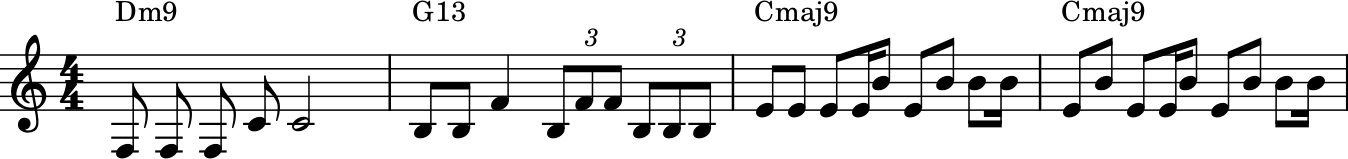

In [107]:
generator.print_song()

In [ ]:
generator.play_song()